# Process Optimization 2025/26: Course Project - **Solution**


The project is testing your comprehension of the concepts in the lecture as well as your understanding of optimization in Python. It includes material which has not yet been covered in the lecture and exercise but will be discussed in the upcoming weeks.

Your results in the course project will count as bonus points towards the exam, adding at most 15% of the exam points.

You have to solve the problems on your own, *collusion is strictly prohibited*.

Please rename the jupyter notebook `ProcOpt_Project_lastname_firstname.ipynb` and answer below. Please submit on the elearning platform. Please submit only the completed Jupyter notebook with your answers. It is not necessary to create a separate PDF file or similar.

### The deadline for the project is **Thu 8th Jan 2026 , 23:59**.

## 1. Multiple choice **(24P)**
Every question has four possible answers. Indicate the correct answers using `[x]`. Every single statement (true/false) is worth **1P**. If no answer is indicated, **0P** are awarded for the question.

#### a)   Which methods use gradient information?  **(4P)**

- [x]   Gradient descent
- [x]   Newton's method
- [x]   Quasi-Newton
- [x]   Trust region method

#### b)   When is a local optimum a global optimum?  **(4P)**

- [ ]   convex objective, convex equality constraints
- [ ]   linear objective, convex equality constraints
- [ ]   linear objective, nonlinear inequality constraints
- [x]   convex objective, linear inequality constraints

#### c)   For which methods can the descent condition be violated?  **(4P)**

- [ ]   Quasi-Newton
- [x]   Newton-Raphson
- [ ]   Gradient descent
- [ ]   Levenberg-Marquard

#### d)   Which statements on linear programming problems are correct?  **(4P)**

- [ ]   There is always an optimum.
- [ ]   There is always exactly one optimum.
- [x]   Every local optimum is a global optimum.
- [ ]   Every global optimum is unique.

#### e)  Which methods are suitable for problems with only inequality constraints?  **(4P)**

- [ ]   reduced gradient method
- [x]   active set method
- [x]   barrier functions
- [x]   penalty functions

#### f)   Which statements on the trust region method are correct?  **(4P)**

- [x]   The radius of the trust region influences the step size.
- [x]   The radius of the trust region impacts the descent direction.
- [ ]   An unconstrained optimization problem is solved in every iteration.
- [x]   If the radius is large enough, a Newton step is carried out.

## 2. Questions **(16P)**

### KKT conditions & active set
#### a)   Consider the following optimization problem. Write and name the KKT conditions for this problem. Use the KKT conditions and the active set algorithm to solve this problem analytically. Start by assuming the active set is empty. **(10P)**

$\min \, \,   x_1^2+2x_2^2 $

$\mathrm{s.t.} \, \,\,\,\,\,\,\,\, x_1+x_2-2 \geq 0 $

$ \qquad \,  -x_1+x_2-1 \geq 0$

$ \qquad x_1,x_2 \in \mathbb{R}$

### Newton methods
#### b)   Formulate mathematically the iteration update to solve an optimization problem using the Newton-Raphson method. Which steps are combined in Newton-Raphson? For which type of problem does the method converge in one step? **(4P)**

_your answer here_

#### c)   In which case does the Newton-Raphson method fail to converge? How can this problem be fixed? **(2P)**

_your answer here_

## 3. Programming (**60P**)

### a) Empirical FT model and ASF distribution (**12P**)

In [6]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import minimize
!pip install pyomo
import pyomo.environ as pyo

#### i) Empirical Fischer-Tropsch model (**8P**)

In [8]:
# calculate mass fractions w of C1-C50 alkanes using corrected ASF distribution
def get_mass_fractions(x):
    T, p , y_H2 = x
    y_CO = 1 - y_H2
    #calculate selectivity by (eq1)
    S_C5 = 1.7 - 0.0024*T - 0.088*(y_H2/y_CO) + 0.18 + 0.0078*p
    #calculate alpha(eq 2)
    term = -np.log10(S_C5) + 0.25*S_C5
    alpha = 0.75 - 0.373 * np.sqrt(term)
    #calculate w for c1 to c4 (Table 1 & eq 5)
    w_n = np.zeros(50)
    ref_C1_C4 = np.array([5.6, 1.1, 2.067, 3.133]) / 100
    sum_ref = 0.119
    S_C1_4 = 1 - S_C5
    CF = S_C1_4 / sum_ref
    w_n[0:4] = ref_C1_C4 * CF
    #calculate w for c5 to c50 (eq3)
    for n in range(5,51):
        idx = n - 1
        w_n[idx] = (alpha**(n-1)) * ((1 - alpha)**2) * n
    return w_n

#### ii) Plot corrected ASF distribution for different temperatures (**4P**)

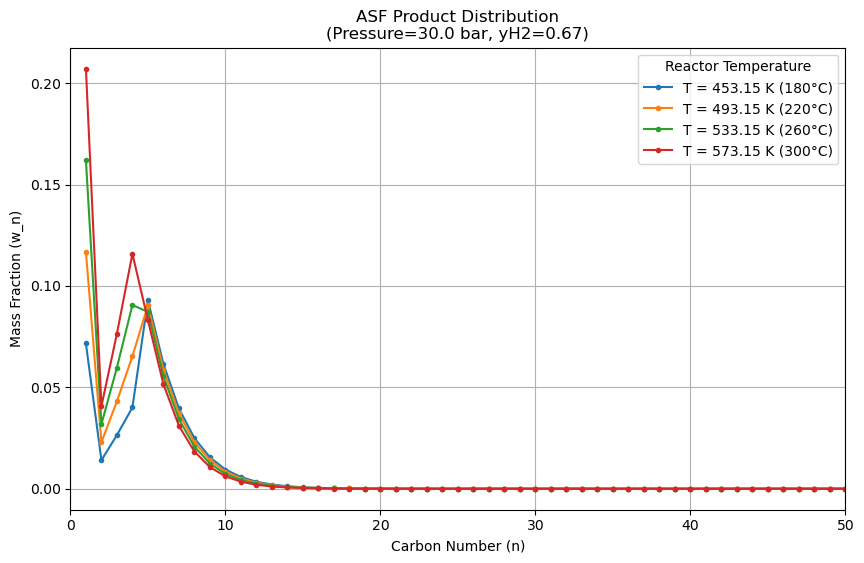

In [10]:
p_fixed = 30.0       
yH2_fixed = 0.67     
temperatures = [453.15, 493.15, 533.15, 573.15] 
carbon_numbers = np.arange(1, 51) 
plt.figure(figsize=(10, 6))
for T in temperatures:
    x_input = [T, p_fixed, yH2_fixed]
    w_n_result = get_mass_fractions(x_input)
    temp_c = T - 273.15
    plt.plot(carbon_numbers, w_n_result, marker='o', markersize=3, label=f"T = {T} K ({temp_c:.0f}°C)")
plt.title(f"ASF Product Distribution\n(Pressure={p_fixed} bar, yH2={yH2_fixed})")
plt.xlabel("Carbon Number (n)")
plt.ylabel("Mass Fraction (w_n)")
plt.legend(title="Reactor Temperature")
plt.grid(True)
plt.xlim(0, 50)
plt.show()

### b) Nonlinear programming (**22P**)

#### i) Formulate the NLP (**7P**)

your answer here
1. Decision Vector x: x = [T, p, yH2, SC5+, alpha, SC1-4, w1, ..., w50, w50+]^T
2. Objective Function: Minimize the negative sum of C8-C16 mass fractions: min J(x) = -1 * sum(wn) for n = 8 to 16
3. Equality Constraints h(x) = 0:
4. h1 (SC5+ Model): SC5+ - (1.7 - 0.0024T - 0.088(yH2/(1-yH2)) + 0.18 + 0.0078*p) = 0
5. h2 (Alpha Model): alpha - (0.75 - 0.373 * sqrt(-log10(SC5+) + 0.25*SC5+)) = 0
6. h3 (Selectivity Balance): SC1-4 - (1 - SC5+) = 0
7. h4 (C1-C4 Fractions): wn - w_ref_n * (SC1-4 / 0.119) = 0 (for n=1 to 4)
8. h5 (ASF Distribution): wn - alpha^(n-1) * (1-alpha)^2 * n = 0 (for n=5 to 50)
9. h6 (Normalization): 1 - (sum(wn for n=1 to 50) + w50+) = 0
10. Bounds (Inequality Constraints): As defined in Eqs (6)-(12)

#### ii) Dimension and degrees of freedom (**2P**)

_your answer here_
DOF = (variable) - (equality constraint)
        57       -     54 = 3 DOF

#### iii) Implement and solve the NLP (**11P**)

In [17]:
# objective: maximize sum of w_8..w_16
ref_C1_C4 = np.array([5.6, 1.1, 2.067, 3.133]) / 100
sum_ref = 0.119
def get_initial_guess():
    T = (453.15 + 573.15) / 2         #taking average operating conditions for calculation of x to give a start to solver.
    p = (30 + 55) / 2
    y_H2 = (0.62 + 0.72)/ 2
    y_CO = 1 - y_H2
    #calculate selectivity by (eq1)
    S_C5 = 1.7 - 0.0024*T - 0.088*(y_H2/y_CO) + 0.18 + 0.0078*p
    #calculate alpha(eq 2)
    term = -np.log10(S_C5) + 0.25*S_C5
    alpha = 0.75 - 0.373 * np.sqrt(term)
    # Calculate S_C1-4 (Eq 4)
    S_C1_4 = 1 - S_C5
    # Calculate w1-w50
    w = np.zeros(50)
    CF = S_C1_4 / sum_ref
    w[0:4] = ref_C1_C4 * CF
    # calculate c5-c50
    n = np.arange(5, 51)
    w[4:50] = (alpha**(n-1)) * ((1 - alpha)**2) * n
    # w50+ 
    w50_plus = 1 - np.sum(w)
    x0 = np.concatenate(([T, p, y_H2, S_C5, alpha, S_C1_4], w, [w50_plus]))
    return x0
# Objective function
def objective(x):
    w_8_16_sum = np.sum(x[13:22])  #because w1 is at index 6
    return -w_8_16_sum            #negative because minimization
# Constrains
def constraint_equations(x):
    T, p, y_H2, S_C5, alpha, S_C1_4 = x[0:6]
    w = x[6:56]
    w50_plus = x[56]
    y_CO = 1 - y_H2
    eqs = []
    #S_C5 model (eq 1)
    sc5_model = 1.7 - 0.0024*T - 0.088*(y_H2/y_CO) + 0.18 + 0.0078*p
    eqs.append(S_C5 - sc5_model)
    #Alpha model (eq 2)
    term = -np.log10(S_C5) + 0.25 * S_C5
    if term < 0: term = 1e-6 
    alpha_model = 0.75 - 0.373 * np.sqrt(term)
    eqs.append(alpha - alpha_model)
    #S_C1-4 balance (eq 4)
    eqs.append(S_C1_4 - (1 - S_C5))
    #w1-w4 (eq 5)
    CF = S_C1_4 / sum_ref
    eqs.extend(w[0:4] - ref_C1_C4 * CF)
    #w5-w50 (eq 3)
    n = np.arange(5, 51)
    w_asf = (alpha**(n-1)) * ((1-alpha)**2) * n
    eqs.extend(w[4:50] - w_asf)
    # Normalization
    total_mass = np.sum(w) + w50_plus
    eqs.append(1 - total_mass)
    return np.array(eqs)
#optimization satup
# T (453-573K), p (30-55bar), y_H2 (0.62-0.72)
bounds_knobs = [(453.15, 573.15), (30, 55), (0.62, 0.72)]
# S_C5, alpha, S_C1_4 must be between 0 and 1
bounds_intermediates = [(0, 1), (0, 1), (0, 1)]
# All 51 mass fractions must be between 0 and 1
bounds_fractions = [(0, 1)] * 51  
my_bounds = bounds_knobs + bounds_intermediates + bounds_fractions
x0 = get_initial_guess()
solution = minimize(objective, x0, method='SLSQP', bounds=my_bounds, constraints={'type': 'eq', 'fun': constraint_equations})
if solution.success:
    print("Optimization Complete.")
    best_x = solution.x
    best_T   = best_x[0]
    best_p   = best_x[1]
    best_y_H2 = best_x[2]
    print(f"Optimal Temperature: {best_T:.2f} K")
    print(f"Optimal Pressure:    {best_p:.2f} bar")
    print(f"Optimal Hydrogen:    {best_y_H2:.2f}")
else:
    print("Something went wrong:", solution.message)


Optimization Complete.
Optimal Temperature: 513.15 K
Optimal Pressure:    42.50 bar
Optimal Hydrogen:    0.62


your answer here

#### iv) Plot optimal ASF distribution at optimal conditions (**2P**)

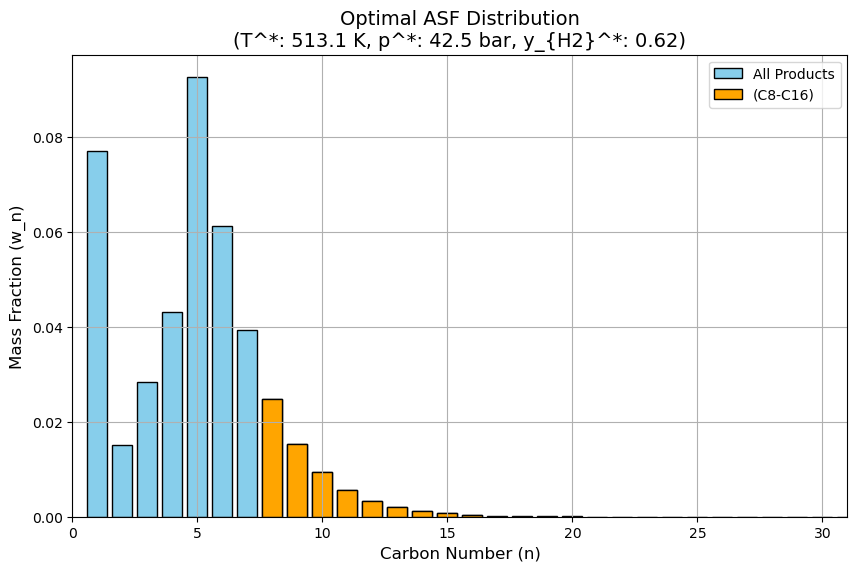

In [26]:
if 'solution' in locals() and solution.success:
    best_x = solution.x    
    T_opt   = best_x[0]
    p_opt   = best_x[1]
    y_H2_opt = best_x[2]
    w_optimal = best_x[6:56]
    carbon_numbers = np.arange(1, 51)
    plt.figure(figsize=(10, 6))
    plt.bar(carbon_numbers, w_optimal, color='skyblue', edgecolor='black', label='All Products')
    C8_16_range_n = carbon_numbers[7:16]
    C8_16_range_w = w_optimal[7:16]
    plt.bar(C8_16_range_n, C8_16_range_w, color='orange', edgecolor='black', label='(C8-C16)')
    plt.xlabel('Carbon Number (n)', fontsize=12)
    plt.ylabel('Mass Fraction (w_n)', fontsize=12)
    plt.title(f'Optimal ASF Distribution\n(T^*: {T_opt:.1f} K, p^*: {p_opt:.1f} bar, y_{{H2}}^*: {y_H2_opt:.2f})', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 31)  
    plt.show()
else:
    print("Cannot plot: No valid solution found. Please run the optimization code first.")

### c) Mixed-integer nonlinear programming (**26P**)

#### i) Introduce binary variables and formulate mixed-integer constraints (**6P**)

_your answer here_
1. binery decesion variable:
z_syn,k = 1 if syngas mixture k is selected
z_sym,k = 0 otherwise
2. target product selection:
z_prod,m = 1 if product gruop m is selected maximization
z_prod,m = 0
3. mixed-integer constrains
sum(k= 1,3)z_syn,k = 1
z_prod,gas + z_prod,ker + z_pro,die = 1
5. linking constrains:
yH2 = 0.62*z_syn,1 + 0.67*zsyn,2 + 0.72*z_syn,3
6. objective function formulation:
max_x,z = z_pro,Gas(sum(n=1,7)) + z_prod,Ker(sum(n= 8,16)) + z_pro,die(sum(n=17,25))

#### ii) Implement and solve the MINLP (**20P**)

In [44]:
# install optimization solvers from idaes python package to be used for optimization with pyomo
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

_your answer here_

In [ ]:
def solve_ft_minlp():
    # 1. Create the Model
    m = ConcreteModel(name="Fischer_Tropsch_MINLP")

    # SETS
    # Carbon numbers 1 to 50
    m.N = RangeSet(1, 50)
    # Syngas options (1, 2, 3)
    m.SynOptions = RangeSet(1, 3)
    # Target product options (1=Gasoline, 2=Kerosene, 3=Diesel)
    m.TargetOptions = RangeSet(1, 3)

    # PAMETERS
    # Reference mass fractions for C1-C4 (from Table 1)
    # CH4 (5.6), C2H6 (1.1), C3H8 (2.067), C4H10 (3.133) -> Sum = 11.9
    ref_fractions = {1: 5.6, 2: 1.1, 3: 2.067, 4: 3.133}
    
    # Syngas H2 mole fractions
    syn_vals = {1: 0.62, 2: 0.67, 3: 0.72}

    # --- DECISION VARIABLES ---
    # Continuous Variables
    m.T = Var(bounds=(453.15, 573.15), initialize=500.0) 
    m.p = Var(bounds=(30, 55), initialize=30.0)          
    m.y_H2 = Var(bounds=(0.62, 0.72))                    
    
    m.S_C5_plus = Var(bounds=(0.001, 1.0)) 
    m.alpha = Var(bounds=(0.0, 1.0))       
    m.w = Var(m.N, bounds=(0, 1))          

    # Binary Variables
    m.z_syn = Var(m.SynOptions, domain=Binary)    
    m.z_target = Var(m.TargetOptions, domain=Binary) 

    # --- CONSTRAINTS ---
    # 1. Binary Logic Constraints (Exactly one chosen)
    def rule_one_syngas(model):
        return sum(model.z_syn[k] for k in model.SynOptions) == 1
    m.c_one_syngas = Constraint(rule=rule_one_syngas)
    def rule_one_target(model):
        return sum(model.z_target[k] for k in model.TargetOptions) == 1
    m.c_one_target = Constraint(rule=rule_one_target)
    # 2. Link Binary Syngas Choice to Continuous y_H2
    def rule_link_yH2(model):
        return model.y_H2 == sum(syn_vals[k] * model.z_syn[k] for k in model.SynOptions)
    m.c_link_yH2 = Constraint(rule=rule_link_yH2)
    # 3. Process Model Equations (Physics)
    def rule_S_C5_plus(model):
        y_co = 1 - model.y_H2
        return model.S_C5_plus == 1.7 - 0.0024*model.T - 0.088*(model.y_H2/y_co) + 0.18 + 0.0078*model.p
    m.c_S_C5_plus = Constraint(rule=rule_S_C5_plus)
    # Eq (2): Alpha Calculation
    def rule_alpha(model):
        return model.alpha == 0.75 - 0.373 * sqrt(-log10(model.S_C5_plus)) + 0.25 * model.S_C5_plus
    m.c_alpha = Constraint(rule=rule_alpha)

    # Eq (3), (4), (5): Mass Fractions w_n
    def calc_S_C1_4(model):
        return 1 - model.S_C5_plus
    def calc_CF(model):
        return calc_S_C1_4(model) / 0.119
    def rule_w_n(model, n):
        if n <= 4:
            # Short chain: Reference * CF
            return model.w[n] == ref_fractions[n] * 0.01 * calc_CF(model) # *0.01 because table is wt%
        else:
            # Long chain: ASF distribution
            # w_n = alpha^(n-1) * (1-alpha)^2 * n
            return model.w[n] == (model.alpha**(n-1)) * ((1 - model.alpha)**2) * n
    m.c_w_n = Constraint(m.N, rule=rule_w_n)

    # OBJECTIVE FUNCTION
    # Group 1: C1-C7
    sum_gasoline = sum(m.w[n] for n in range(1, 8))
    # Group 2: C8-C16
    sum_kerosene = sum(m.w[n] for n in range(8, 17))
    # Group 3: C17-C25
    sum_diesel = sum(m.w[n] for n in range(17, 26))
    def rule_objective(model):
        return (model.z_target[1] * sum_gasoline + 
                model.z_target[2] * sum_kerosene + 
                model.z_target[3] * sum_diesel)
    
    m.obj = Objective(rule=rule_objective, sense=maximize)

    #SOLVER
    solver = SolverFactory('bonmin') 
    try:
        results = solver.solve(m, tee=True)
    except Exception as e:
        print(f"Solver Error: {e}")
        print("Ensure you have a valid MINLP solver (like bonmin) installed.")
        return

    # PRINT RESULTS
    print("\n" + "="*40)
    print("OPTIMIZATION RESULTS (MINLP)")
    print("="*40)
    
    # Find which binary is 1
    selected_syn = [k for k in m.SynOptions if value(m.z_syn[k]) > 0.5][0]
    selected_target = [k for k in m.TargetOptions if value(m.z_target[k]) > 0.5][0]
    target_names = {1: "Gasoline (C1-C7)", 2: "Kerosene (C8-C16)", 3: "Diesel (C17-C25)"}
    print(f"Optimal Syngas Mixture Chosen: Option {selected_syn} (y_H2 = {syn_vals[selected_syn]})")
    print(f"Target Product Range Chosen:   {target_names[selected_target]}")
    print("-" * 20)
    print(f"Optimal Temperature (T):       {value(m.T):.2f} K")
    print(f"Optimal Pressure (p):          {value(m.p):.2f} bar")
    print(f"Chain Growth Prob (alpha):     {value(m.alpha):.4f}")
    print(f"Maximized Mass Fraction Sum:   {value(m.obj):.4f}")
    print("="*40)
if __name__ == "__main__":
    solve_ft_minlp()